In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import json

# 1. Carga de datos procesados en el paso anterior
with open('../data/processed/streaming_users_clean.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)

# 2. Selecciono únicamente las variables numéricas para PCA
# Excluimos IDs y variables categóricas que ya analizamos en el EDA
numeric_cols = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
X_numeric = df[numeric_cols]

# 3. Escalamiento de variables (Estandarización)
# Es un requisito obligatorio para PCA, asegurando que las escalas no distorsionen los componentes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# Convertimos a DataFrame para verificar el resultado visualmente
df_scaled = pd.DataFrame(X_scaled, columns=numeric_cols)
print("¡Datos numéricos seleccionados y escalados con éxito!")
df_scaled.head()

¡Datos numéricos seleccionados y escalados con éxito!


,age,monthly_watch_time_mins,customer_support_tickets
0,0.471126,-0.055781,8.420126
1,0.303075,0.017658,0.019200
2,-0.453156,-0.136651,-0.154015
3,0.807229,-0.204296,-0.154015
4,1.479434,-0.121308,-0.067407


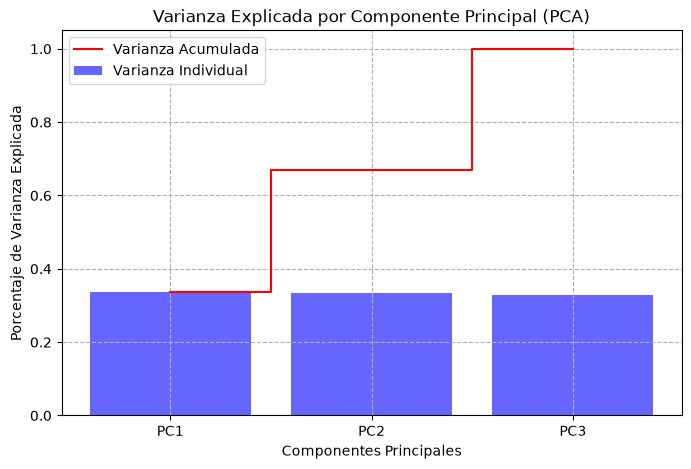

Componente Principal 1 (PC1): explica el 33.58% de la varianza.
Componente Principal 2 (PC2): explica el 33.45% de la varianza.
Componente Principal 3 (PC3): explica el 32.96% de la varianza.
Varianza total acumulada por los dos primeros componentes: 67.04%


In [2]:
# 1. Inicio el PCA para calcular todos los componentes posibles (3 variables = 3 componentes)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 2. Calculo el porcentaje de varianza que explica cada componente
variance_explained = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_explained)

# 3. Grafico la varianza explicada acumulada
plt.figure(figsize=(8, 5))
plt.bar(range(1, 4), variance_explained, alpha=0.6, color='b', label='Varianza Individual')
plt.step(range(1, 4), cumulative_variance, where='mid', color='r', label='Varianza Acumulada')

plt.title('Varianza Explicada por Componente Principal (PCA)')
plt.xlabel('Componentes Principales')
plt.ylabel('Porcentaje de Varianza Explicada')
plt.xticks(range(1, 4), ['PC1', 'PC2', 'PC3'])
plt.legend(loc='best')
plt.grid(True, linestyle='--')
plt.show()

# Imprimo los valores exactos para el análisis conceptual
for i, var in enumerate(variance_explained):
    print(f"Componente Principal {i+1} (PC{i+1}): explica el {var*100:.2f}% de la varianza.")
print(f"Varianza total acumulada por los dos primeros componentes: {cumulative_variance[1]*100:.2f}%")

### Interpretación del Análisis de Componentes Principales (PCA)

Al aplicar PCA sobre las tres variables numéricas estandarizadas (`age`, `monthly_watch_time_mins` y `customer_support_tickets`), el algoritmo genera tres nuevos componentes ortogonales (PC1, PC2 y PC3). 

El objetivo principal es evaluar si es factible reducir las dimensiones del set de datos perdiendo la menor cantidad de información posible. Observando los resultados impresos y el gráfico de varianza acumulada, podemos tomar una decisión metodológica informada sobre cuántos componentes retener para la posterior etapa de modelado, buscando idealmente capturar la mayor parte de la varianza total del dataset con los primeros componentes principales.